In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
sys.path.insert(0, r'Z:\Users\Gregory\Ca40_multi_photon')
sys.path.insert(0, r'Z:\Users\Gregory\Ca40_multi_photon\raman_simulation')
import useful_funcs
import simulation as s
from scipy.optimize import curve_fit
from uncertainties import *

cb_d = (106/255, 139/255,239/255)
cb_l = (158/255, 190/255,255/255)
cr_d = (214/255, 82/255,68/255)
cr_l = (244/255, 152/255,122/255)

In [2]:
sim4 = s.sim()
sim4.Pr = .195
sim4.Pb = .180
sim4.get_f()
sim4.F_states = True
sim4.b_pi = .33
sim4.b_sp = .373

sim4.get_rabi_frequencies()

In [3]:
Pb_bank = np.array([.180])
sim4.power_scaling(Pb_bank)

power scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 180.0 mW:   0%|          | 0/40 [00:00<?, ?it/s]

In [4]:
w_bank = np.array([1.001, 1.25])
sim4.PS_power = 4
sim4.ϵ = 0
sim4.power_scaling_PS(w_bank, np.pi/sim4.Ω_num_bank[0])

PS scan progress:   0%|          | 0/2 [00:00<?, ?it/s]

spectroscopy, Pb = 180.0 mW:   0%|          | 0/40 [00:00<?, ?it/s]

spectroscopy, Pb = 180.0 mW:   0%|          | 0/40 [00:00<?, ?it/s]

In [5]:
sim2 = s.sim()
sim2.Pr = .195
sim2.Pb = .180
sim2.F_states = True
sim2.get_f()
sim2.b_pi = .33
sim2.b_sp = .373
sim2.get_rabi_frequencies()

In [7]:
sim2.power_scaling(Pb_bank)

power scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 180.0 mW:   0%|          | 0/40 [00:00<?, ?it/s]

In [8]:
w_bank = np.array([1.001, 1.25])
sim2.PS_power = 2
sim2.ϵ = 0
sim2.power_scaling_PS(w_bank, np.pi/sim2.Ω_num_bank[0])

PS scan progress:   0%|          | 0/2 [00:00<?, ?it/s]

spectroscopy, Pb = 180.0 mW:   0%|          | 0/40 [00:00<?, ?it/s]

spectroscopy, Pb = 180.0 mW:   0%|          | 0/40 [00:00<?, ?it/s]

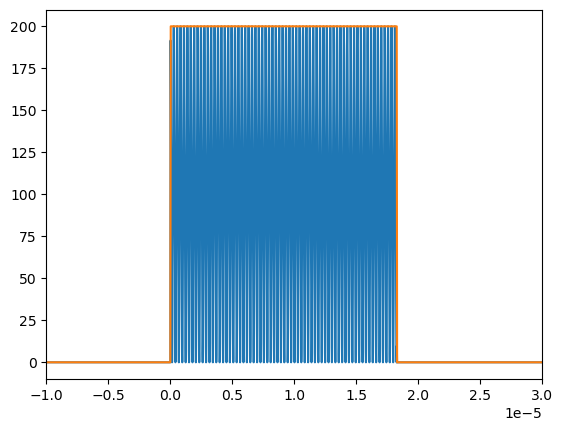

In [10]:
dt = 1e-9
t = np.arange(-150e-6, 200e-6 + dt, dt)
w = sim4.w_num_bank[0]

A = 200.0         
T = np.pi/sim4.Ω_num_bank[0]    
f0 = w/(2*np.pi)     
phi = 0.0

# box car pulse shape

f = w_bank[0]
t2 = (np.pi/sim4.Ω_num_bank[0])*(f-1)
ω = np.pi/(2*t2)

env_sin = np.zeros((len(t)))
m1 = (t > 0) & (t < np.pi/(2*ω))
m2 = (t > np.pi/(2*ω)) & (t < T)
m3 = (t > T) & (t <T + np.pi/(2*ω))
env_sin[m1] = np.sin(ω*(t)[m1] )**2
env_sin[m2] = (t/t)[m2]
env_sin[m3] = np.sin(ω*(t -T - np.pi/(2*ω))[m3] )**2                     
pulse_sin1 = (A/2)*(1 + np.cos(2*np.pi*f0*t + phi)) * (env_sin**.5)


plt.plot(t, pulse_sin1)
plt.plot(t, env_sin*200)
plt.xlim(-10e-6,30e-6)
plt.show()

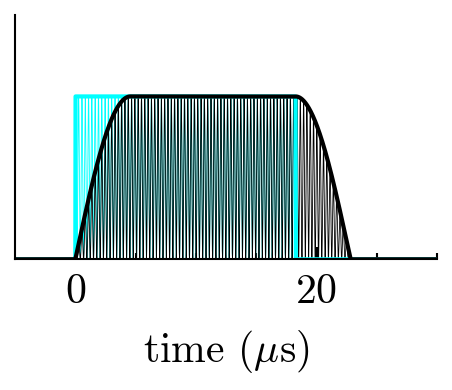

In [11]:
dt = 1e-9
t = np.arange(-150e-6, 200e-6 + dt, dt)
w = sim4.w_num_bank[0]

A = 200.0         
T = np.pi/sim4.Ω_num_bank[0]    
f0 = w/(2*np.pi)     
phi = 0.0

# box car pulse shape
f = w_bank[0]
t2 = (np.pi/sim4.Ω_num_bank[0])*(f-1)
ω = np.pi/(2*t2)

env_sin = np.zeros((len(t)))
m1 = (t > 0) & (t < np.pi/(2*ω))
m2 = (t > np.pi/(2*ω)) & (t < T)
m3 = (t > T) & (t <T + np.pi/(2*ω))
env_sin[m1] = np.sin(ω*(t)[m1] )**2
env_sin[m2] = (t/t)[m2]
env_sin[m3] = np.sin(ω*(t -T - np.pi/(2*ω))[m3] )**2                     
pulse_sin1 = (A/2)*(1 + np.cos(2*np.pi*f0*t + phi)) * (env_sin**.5)

# sin^2
f = w_bank[1]
t2 = (np.pi/sim4.Ω_num_bank[0])*(f-1)
ω = np.pi/(2*t2)

env_sin2 = np.zeros((len(t)))
m1 = (t > 0) & (t < np.pi/(2*ω))
m2 = (t > np.pi/(2*ω)) & (t < T)
m3 = (t > T) & (t <T + np.pi/(2*ω))
env_sin2[m1] = np.sin(ω*(t)[m1] )**2
env_sin2[m2] = (t/t)[m2]
env_sin2[m3] = np.sin(ω*(t -T - np.pi/(2*ω))[m3] )**2                     
pulse_sin2 = (A/2)*(1 + np.cos(2*np.pi*f0*t + phi)) * (env_sin2**.5)



with plt.style.context(['science','no-latex']):
    plt.figure(figsize=(2, 1.5), dpi=300)
    #plt.plot(t*1e6, pulse_sin1, linewidth=.4, color = 'magenta')
    
    
    plt.plot(t*1e6, pulse_sin1, linewidth=.2, color = 'cyan')
    plt.plot(t*1e6, pulse_sin2, linewidth=.2, color = 'black')
    
    plt.plot(t*1e6, env_sin**.5*200, color = 'cyan')
    plt.plot(t*1e6, env_sin2**.5*200, color = 'black')
    
    plt.xlabel(r"time ($\mu$s)")

    #plt.title("Pulse shape")
    plt.tight_layout()
    plt.xlim(-5, 30)
    plt.ylim(0,300)
    ax = plt.gca()

    # remove spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # remove ALL ticks on top and right (major + minor)
    ax.tick_params(
        axis='both',
        which='both',
        top=False,
        right=False,
        left = False
    )
    ax.yaxis.set_visible(False)
    plt.ylabel("pulse amplitude  ")
    plt.show()

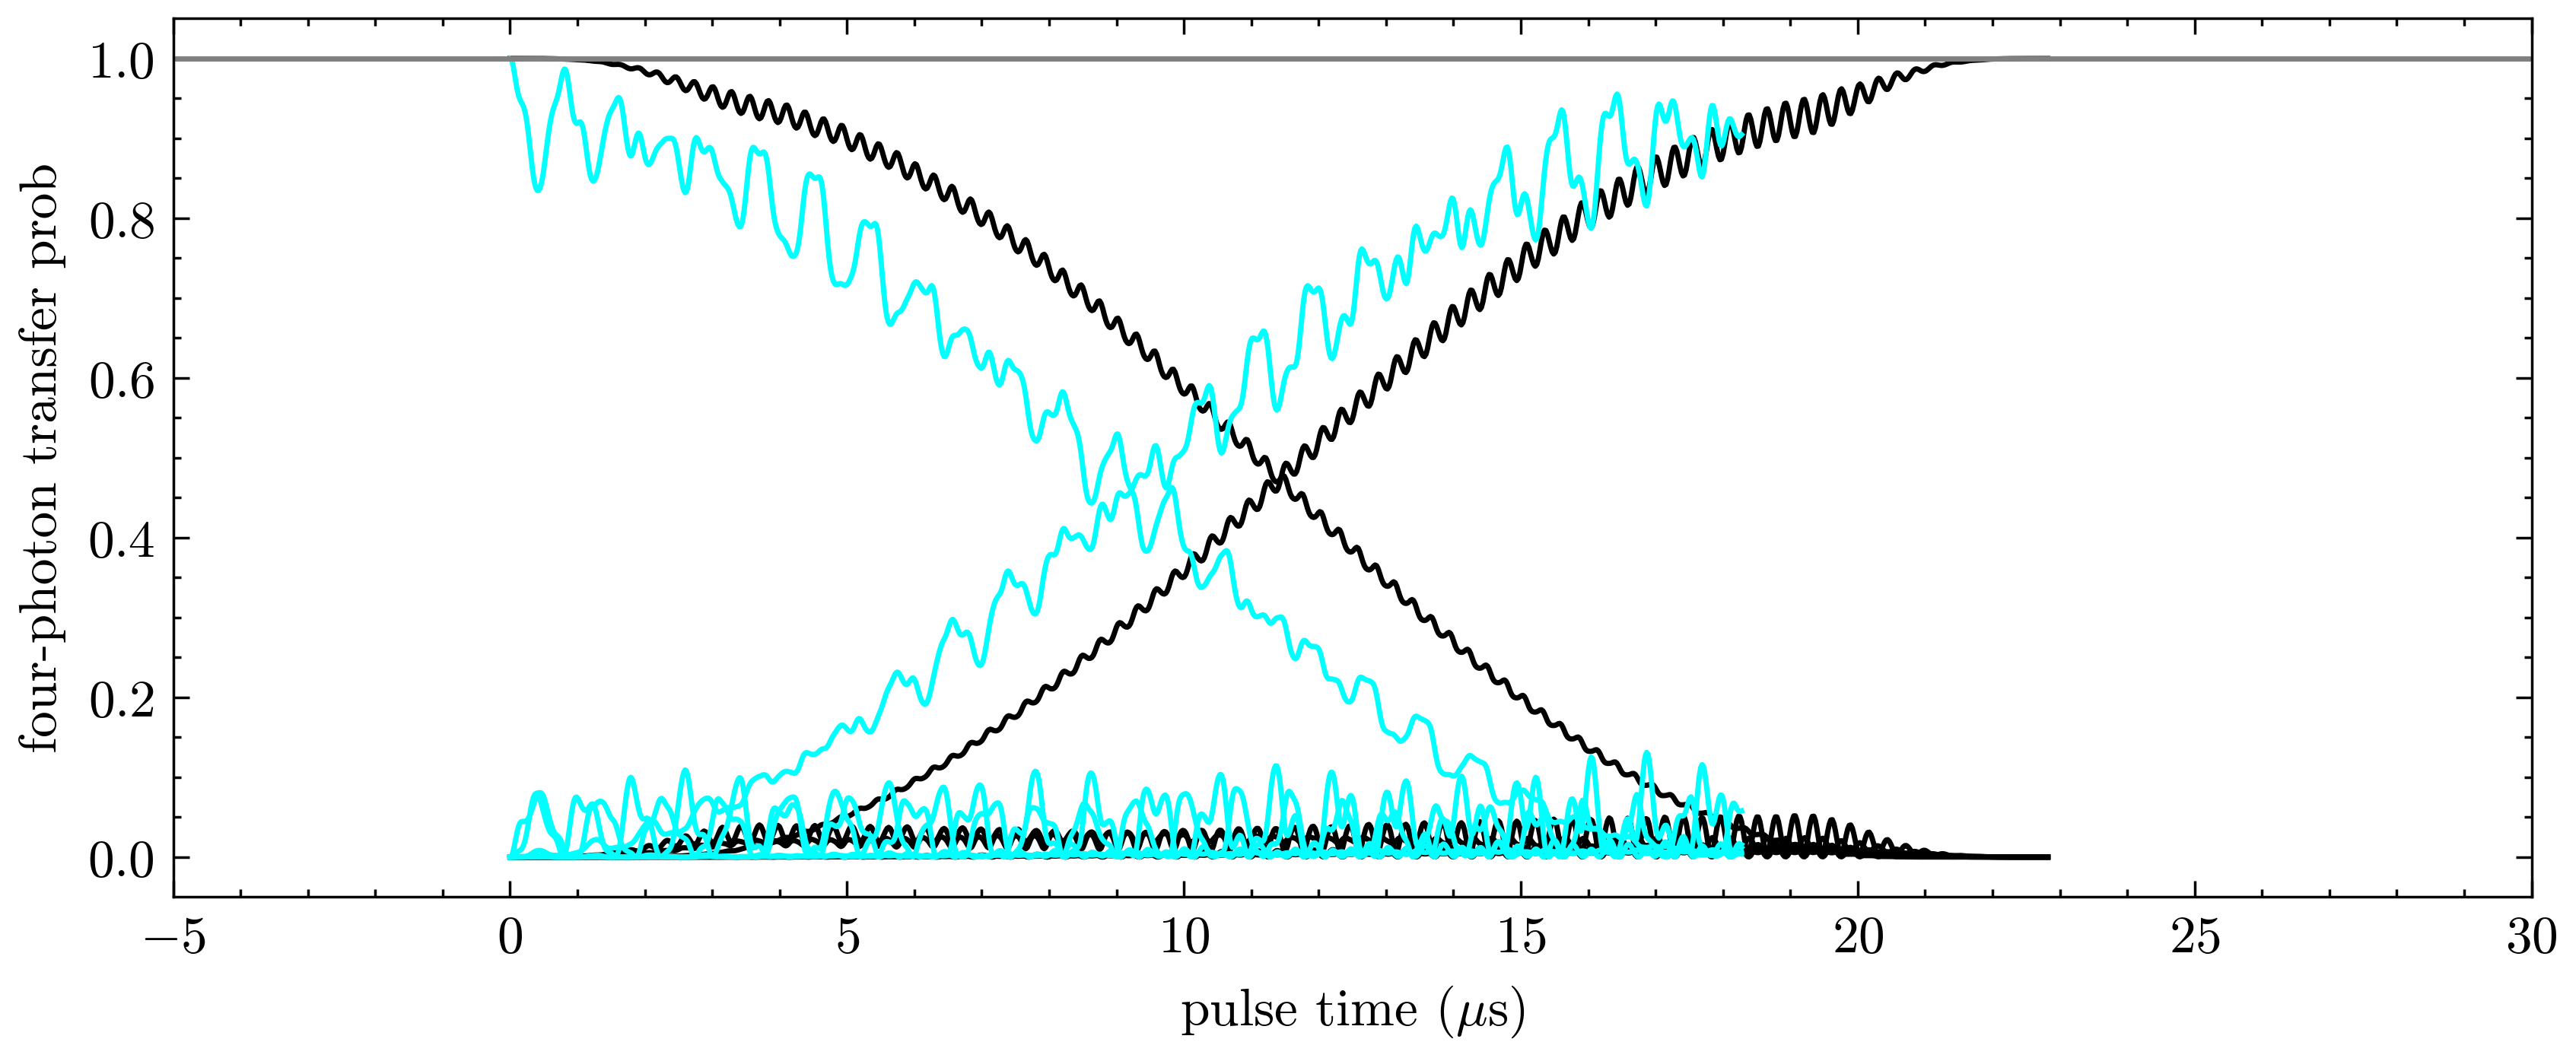

In [21]:
ind1 = -1
ind2 = 0

with plt.style.context(['science','no-latex']):
    plt.figure(dpi = 500, figsize = (8,3))
    
    
    plt.plot(sim4.t_bank[ind1]*1e6, sim4.p52_bank[ind1], color = 'black')
    plt.plot(sim4.t_bank[ind1]*1e6, sim4.p32_bank[ind1], color = 'black')
    plt.plot(sim4.t_bank[ind1]*1e6, sim4.p12_bank[ind1], color = 'black')
    plt.plot(sim4.t_bank[ind1]*1e6, sim4.m12_bank[ind1], color = 'black')
    plt.plot(sim4.t_bank[ind1]*1e6, sim4.m32_bank[ind1], color = 'black')
    plt.plot(sim4.t_bank[ind1]*1e6, sim4.m52_bank[ind1], color = 'black')
    plt.ylabel(r'four-photon transfer prob')
    plt.xlabel(r'pulse time ($\mu$s)')
    
    
    plt.plot(sim4.t_bank[ind2]*1e6, sim4.p52_bank[ind2], color = 'cyan')
    plt.plot(sim4.t_bank[ind2]*1e6, sim4.p32_bank[ind2], color = 'cyan')
    plt.plot(sim4.t_bank[ind2]*1e6, sim4.p12_bank[ind2], color = 'cyan')
    plt.plot(sim4.t_bank[ind2]*1e6, sim4.m12_bank[ind2], color = 'cyan')
    plt.plot(sim4.t_bank[ind2]*1e6, sim4.m32_bank[ind2], color = 'cyan')
    plt.plot(sim4.t_bank[ind2]*1e6, sim4.m52_bank[ind2], color = 'cyan')
    
    
    
    # plt.plot(sim4.t_bank[ind3]*1e6, sim4.p52_bank[ind3], color = 'magenta')
    # plt.plot(sim4.t_bank[ind3]*1e6, sim4.p32_bank[ind3], color = 'magenta')
    # plt.plot(sim4.t_bank[ind3]*1e6, sim4.p12_bank[ind3], color = 'magenta')
    # plt.plot(sim4.t_bank[ind3]*1e6, sim4.m12_bank[ind3], color = 'magenta')
    # plt.plot(sim4.t_bank[ind3]*1e6, sim4.m32_bank[ind3], color = 'magenta')
    # plt.plot(sim4.t_bank[ind3]*1e6, sim4.m52_bank[ind3], color = 'magenta')
    plt.axhline(1, color = 'grey')
    plt.xlim(-5, 30)
    plt.show()

In [22]:
def get_spectrum(t, pulse):
    X = np.fft.fftshift(np.fft.fft(pulse)) * dt
    f = np.fft.fftshift(np.fft.fftfreq(len(t), d=dt))
    spectrum = np.abs(X)
    spectrum /= spectrum.max() if spectrum.max() != 0 else 1.0
    
    return f, spectrum

f1, spectrum_1 = get_spectrum(t, pulse_sin1)
f2, spectrum_2 = get_spectrum(t, pulse_sin2)

mask = (f2 > 0*1e6) & (f2 < 12e6)
f2 = f2[mask]
spectrum_2 = spectrum_2[mask]
spectrum_2 = 2*spectrum_2 / max(spectrum_1)

mask = (f1 > 0*1e6) & (f1 < 12e6)
f1 = f1[mask]
spectrum_1 = spectrum_1[mask]
spectrum_1 = 2*spectrum_1 / max(spectrum_1)

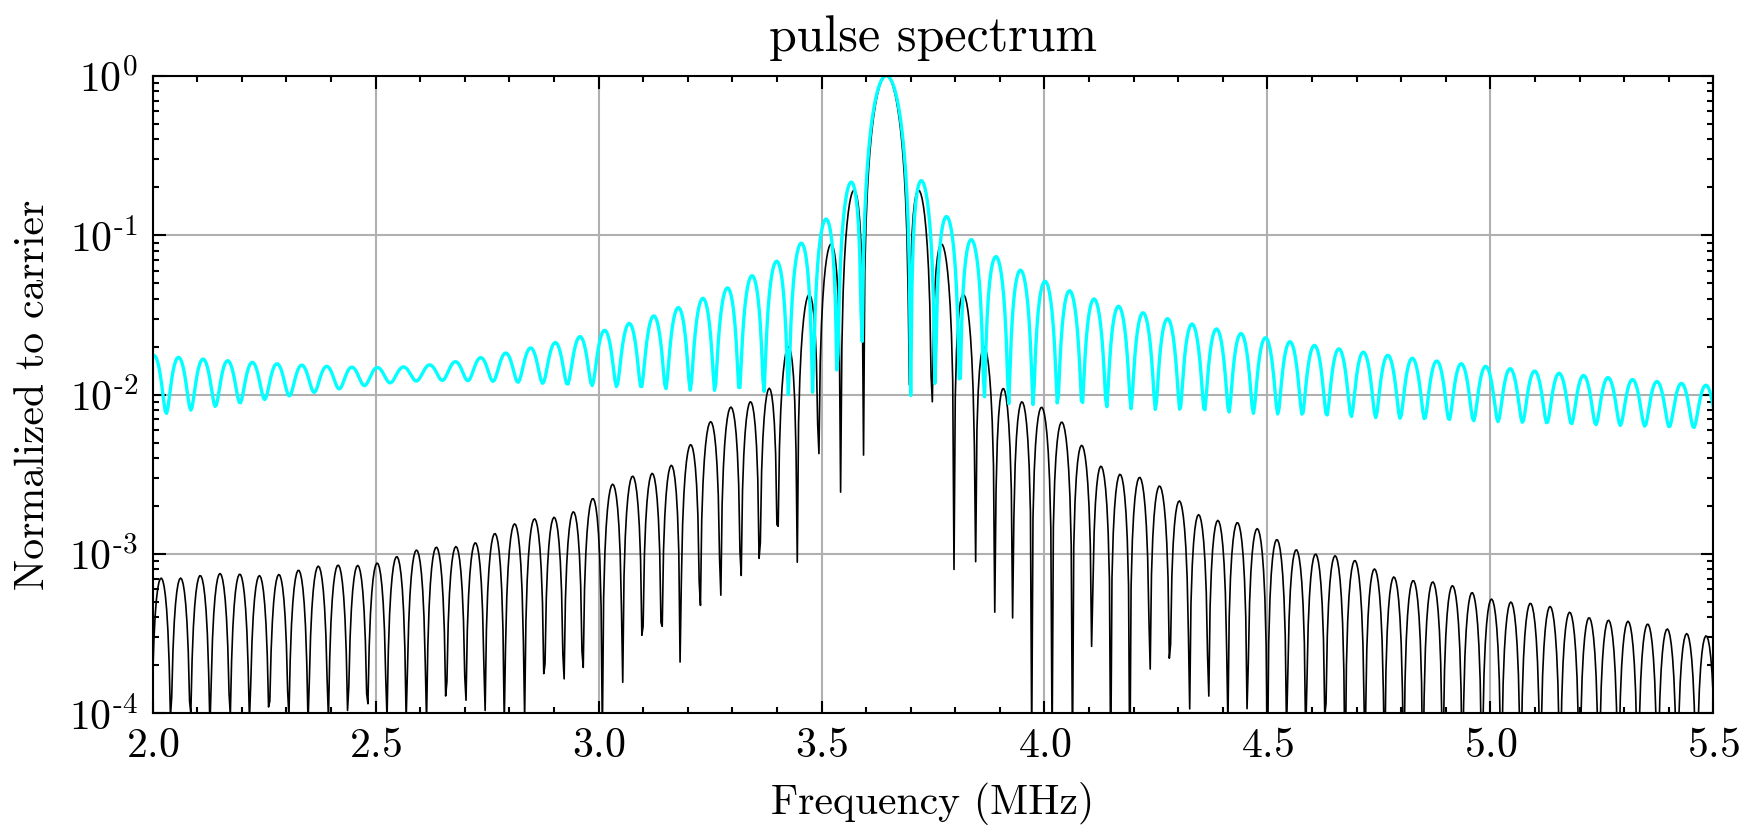

In [23]:
with plt.style.context(['science','no-latex']):
    plt.figure(figsize=(6, 3), dpi=300)
    plt.plot(f2/1e6, spectrum_2, linewidth=.4, color = 'black')
    plt.plot(f1/1e6, spectrum_1, linewidth=.8, color = 'cyan')
    #plt.plot(f1/1e6, spectrum_1, linewidth=.4, color = 'magenta')
    plt.xlabel("Frequency (MHz)")
    plt.ylabel("Normalized to carrier")
    plt.title("pulse spectrum")
    plt.xlim(2, 5.5)
    plt.ylim(1e-4, 1)
    plt.tight_layout()
    # plt.axvline(s1,color = 'black')
    # plt.axvline(s2,color = 'black')
    plt.yscale('log')
    plt.grid()
    plt.show()

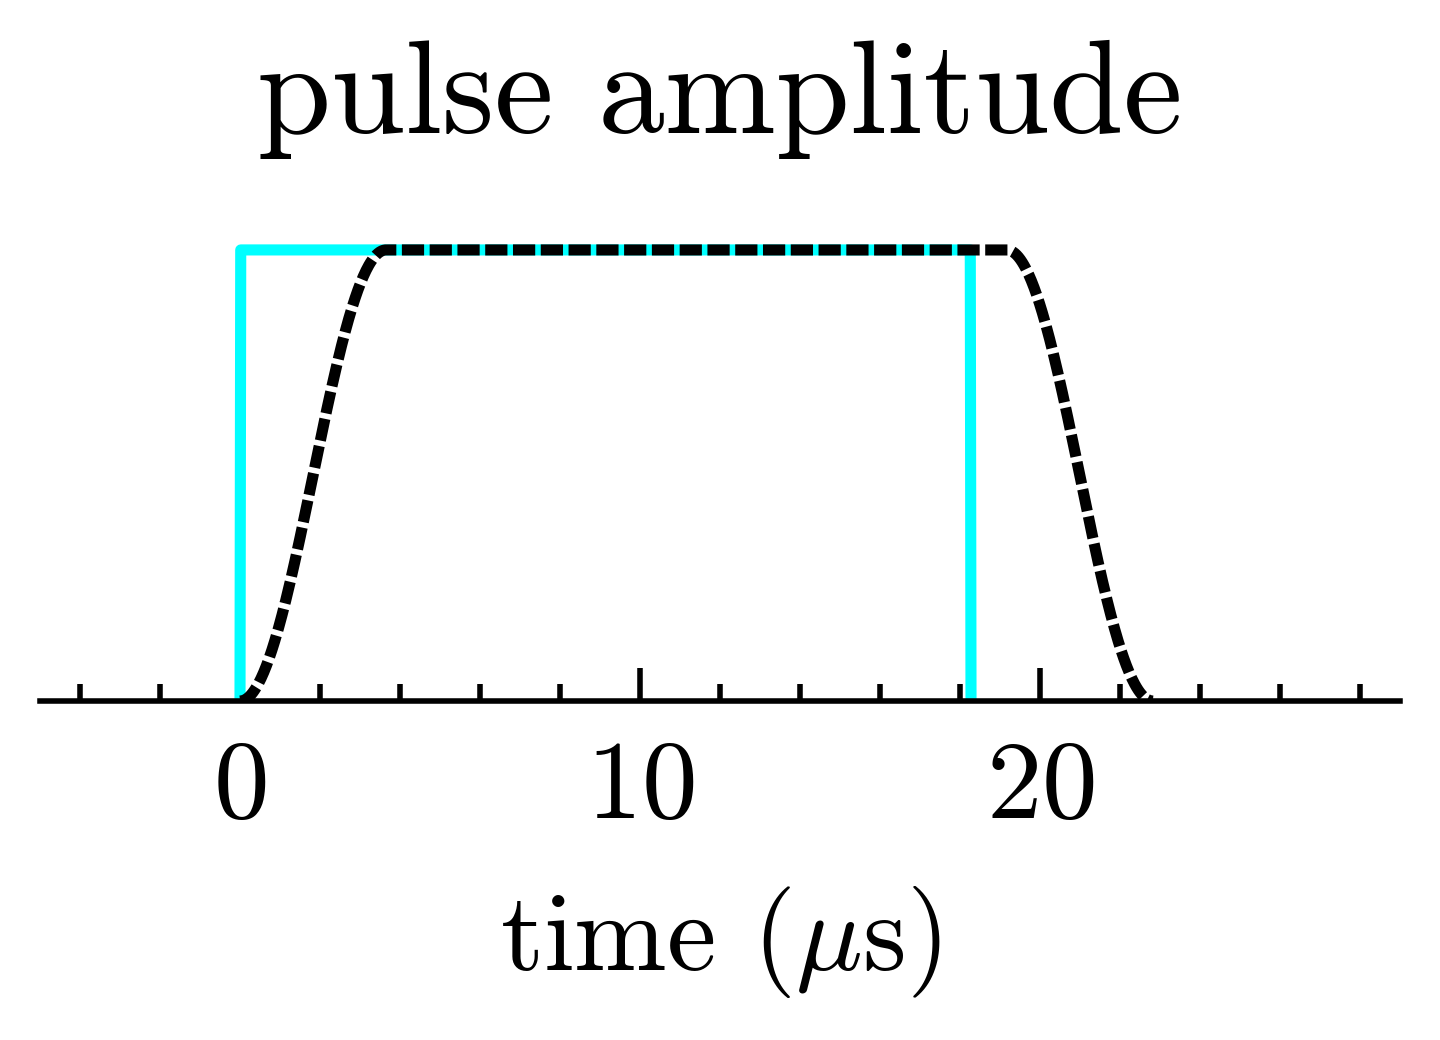

In [24]:
with plt.style.context(['science','no-latex']):
    fig = plt.figure(figsize=(2, 1.5), dpi=800)
    plt.title('pulse amplitude')
    # plt.plot(t*1e6, pulse_sin2*180/200, linewidth=.2, color='cyan')
    # plt.plot(t*1e6, (pulse_sin3/200)*180, linewidth=.2, color='black')
    plt.plot(sim4.t_bank[ind2]*1e6,
             sim4.env_bank[ind2]*sim4.Pb*1e3, color='cyan')
    plt.plot(sim4.t_bank[ind1]*1e6,
             sim4.env_bank[ind1]**.5*sim4.Pb*1e3, color='black',linestyle=(0, (2, .5, 2, .5)))


    plt.xlabel(r"time ($\mu$s)")
    plt.xlim(-5, 29)
    plt.ylim(0, 200)

    ax = plt.gca()

    # remove all y-axis visuals
    ax.yaxis.set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)

    ax.tick_params(axis='both', which='both',
                   top=False, right=False, left=False)

    # MANUAL y-label (this is the key)
    # fig.text(-.02, 0.4, "pulse amplitude",
    #          va='center', rotation='vertical')

    plt.tight_layout()
    plt.show()

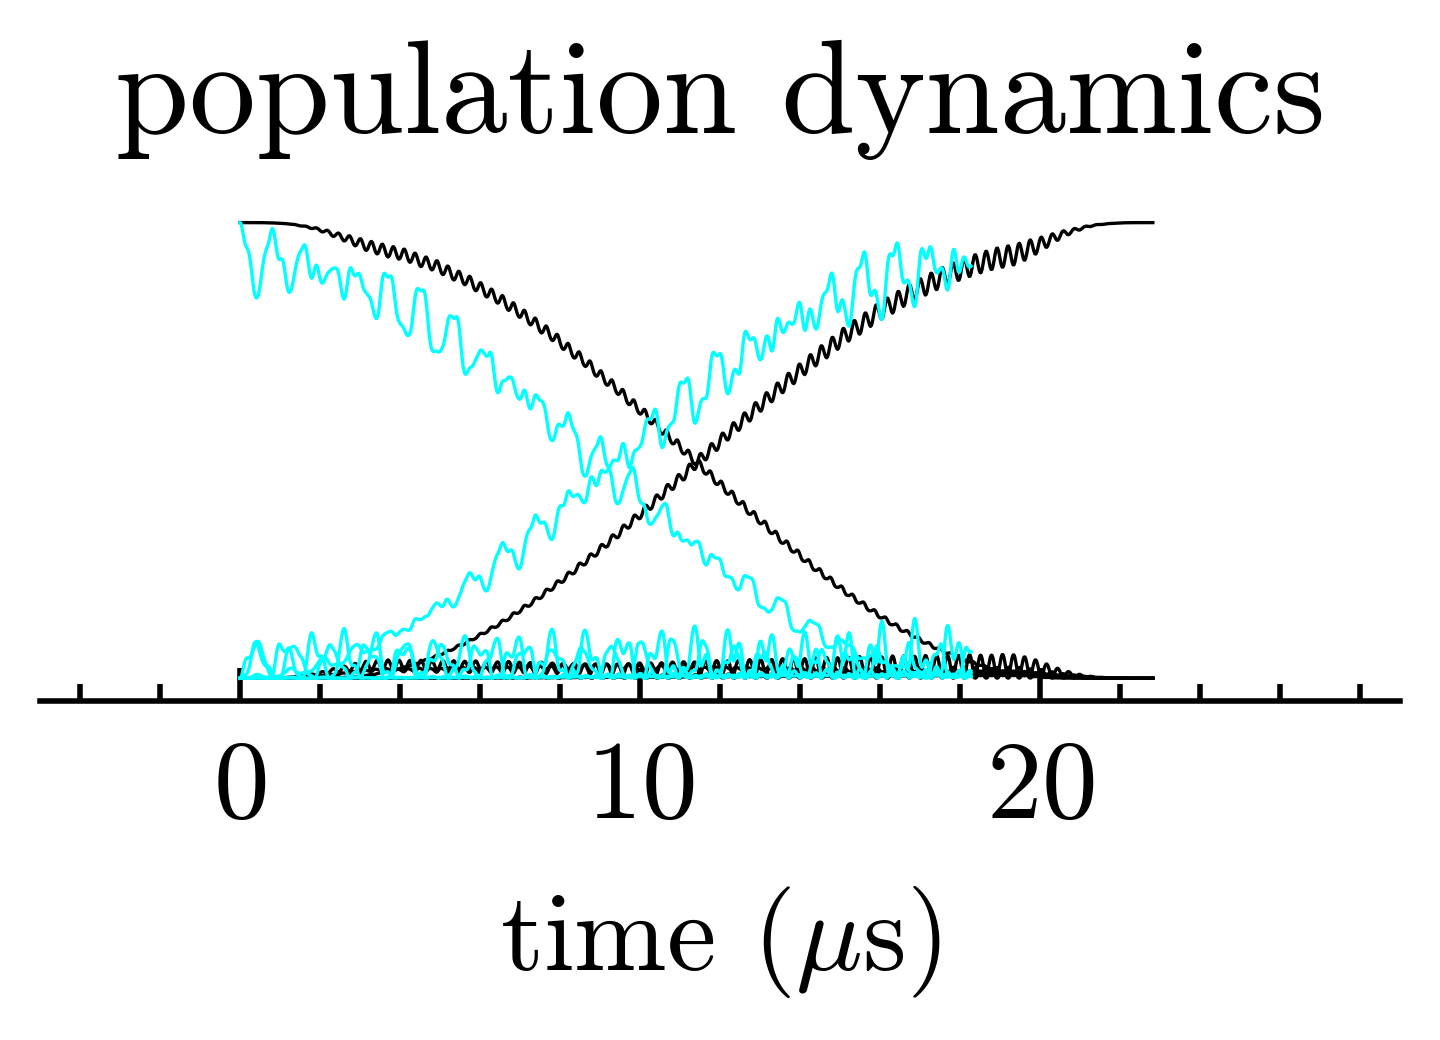

In [25]:
with plt.style.context(['science','no-latex']):
    fig = plt.figure(figsize=(2, 1.5), dpi=800)
    plt.title('population dynamics')
    
    lwd = .3
    
    plt.plot(sim4.t_bank[ind1]*1e6, sim4.p52_bank[ind1], color = 'black', linewidth = lwd)
    plt.plot(sim4.t_bank[ind1]*1e6, sim4.p32_bank[ind1], color = 'black', linewidth = lwd)
    plt.plot(sim4.t_bank[ind1]*1e6, sim4.p12_bank[ind1], color = 'black', linewidth = lwd)
    plt.plot(sim4.t_bank[ind1]*1e6, sim4.m12_bank[ind1], color = 'black', linewidth = lwd)
    plt.plot(sim4.t_bank[ind1]*1e6, sim4.m32_bank[ind1], color = 'black', linewidth = lwd)
    plt.plot(sim4.t_bank[ind1]*1e6, sim4.m52_bank[ind1], color = 'black', linewidth = lwd)
    
    plt.plot(sim4.t_bank[ind2]*1e6, sim4.p52_bank[ind2], color = 'cyan', linewidth = lwd)
    plt.plot(sim4.t_bank[ind2]*1e6, sim4.p32_bank[ind2], color = 'cyan', linewidth = lwd)
    plt.plot(sim4.t_bank[ind2]*1e6, sim4.p12_bank[ind2], color = 'cyan', linewidth = lwd)
    plt.plot(sim4.t_bank[ind2]*1e6, sim4.m12_bank[ind2], color = 'cyan', linewidth = lwd)
    plt.plot(sim4.t_bank[ind2]*1e6, sim4.m32_bank[ind2], color = 'cyan', linewidth = lwd)
    plt.plot(sim4.t_bank[ind2]*1e6, sim4.m52_bank[ind2], color = 'cyan', linewidth = lwd)
    

    plt.xlabel(r"time ($\mu$s)")
    plt.xlim(-5, 29)


    ax = plt.gca()

    # remove all y-axis visuals
    ax.yaxis.set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)

    ax.tick_params(axis='both', which='both',
                   top=False, right=False, left=False)

    # MANUAL y-label (this is the key)
    # fig.text(-.02, 0.4, "pulse amplitude",
    #          va='center', rotation='vertical')

    plt.tight_layout()
    plt.show()

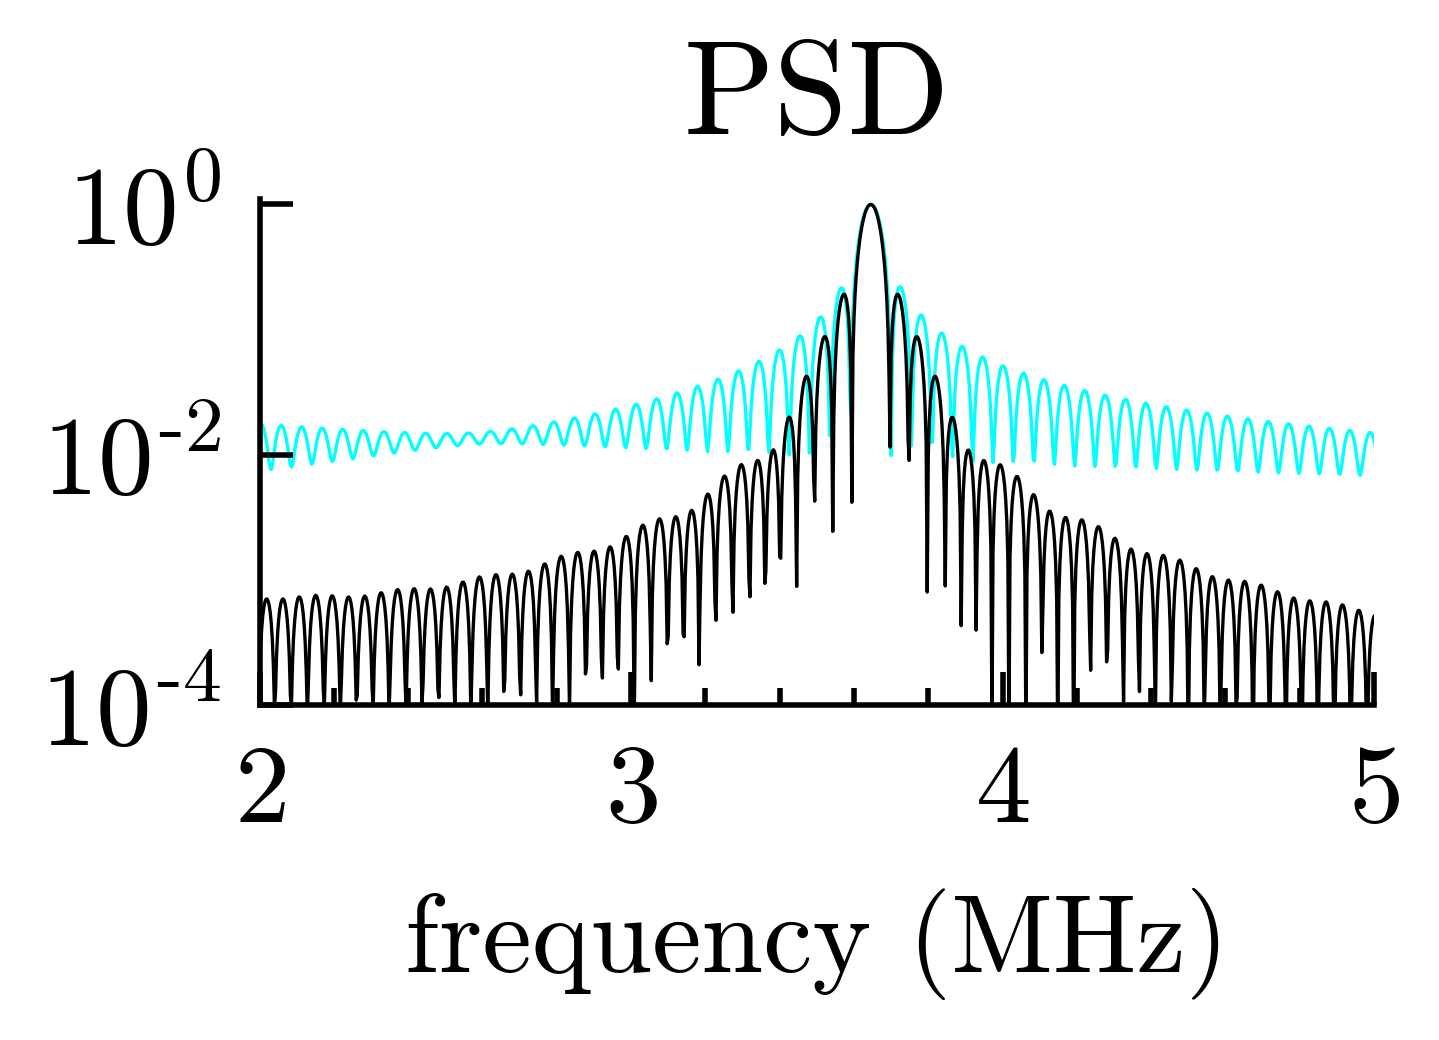

In [27]:
with plt.style.context(['science','no-latex']):
    fig = plt.figure(figsize=(2, 1.5), dpi=800)
    plt.title('PSD')
    
    lwd = .3
    plt.plot(f1/1e6, spectrum_1, linewidth=.3, color = 'cyan')    
    plt.plot(f2/1e6, spectrum_2, linewidth=.3, color = 'black')


    plt.xlabel(r"frequency (MHz)")
    plt.xlim(2, 5)

    plt.yscale('log')
    ax = plt.gca()

    # remove all y-axis visuals
    #ax.yaxis.set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    #ax.spines['left'].set_visible(False)

    ax.tick_params(axis='x', which='both',
                   top=False, right=False)

    ax.tick_params(
    axis='y',
    which='both',
    right=False,   # kill right ticks
    left=True      # keep left ticks
    )
    # MANUAL y-label (this is the key)
    # fig.text(-.02, 0.4, "pulse amplitude",
    #          va='center', rotation='vertical')

    plt.ylim(1e-4, 1.1)
    plt.tight_layout()
    ax = plt.gca()
    ax.set_axisbelow(False)
    plt.show()